# 07 · Forecast monthly review volume and rating (zero-shot, no training)

**Use case:** community managers staff the moderation queue a few months ahead — how many reviews will arrive per
month, and is the average rating drifting?

**Model / lane:** Chronos-2 zero-shot over the project's own `review_time` series — nothing is trained; the cost is
40 + 6 × horizon credits per call.

**Sub-tasks**
1. Reuse the explore project (01)
2. A 6-month forecast of the review **count** with 10 / 50 / 90 % quantiles
3. A 6-month forecast of the **mean rating**
4. Plot history and the forecast band; read the response's calibration flag and warnings

The sample runs 2008 → September 2018 and thins out in its last weeks; the forecast follows that tail — which is what a
forecaster should do.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST_SDK_2' with 17 scopes


In [2]:
p = get_or_create_project(ls, "explore", kind="data_analysis")
before = credits_used(ls)

reusing project 0b6ffd93-08da-4220-9dfa-5b62b5f5951f (amazon-reviews-explore, status=schema_done)
project ready: status=schema_done · type=data_analysis · files=['customer.csv', 'product.csv', 'review.csv']


In [3]:
fc = ls.predict.forecast(project_id=p.id, target="rating", agg="count", window="month", length=6, quantiles=[0.1, 0.5, 0.9])
print("target:", fc["target"], "(count) · window:", fc["window_type"], "× len", fc["window_length"], "· calibrated:", fc.get("calibrated"))
for pt in fc["forecast"]:
    q = pt.get("quantiles") or {}
    print(f"  {str(pt['timestamp'])[:10]}  median {pt['median']:.1f}  band [{float(q.get('0.1', q.get(0.1, 0))):.1f}, {float(q.get('0.9', q.get(0.9, 0))):.1f}]")
print("warnings:", [w["code"] for w in fc.get("warnings", [])])

target: rating (count) · window: month × len 6 · calibrated: True
  2018-10-01  median 0.0  band [0.0, 24.2]
  2018-11-01  median 0.0  band [0.0, 17.2]
  2018-12-01  median 0.0  band [0.0, 21.6]
  2019-01-01  median 0.0  band [0.0, 25.8]
  2019-02-01  median 0.0  band [0.0, 34.6]
  2019-03-01  median 0.0  band [0.0, 49.2]
warnings: ['window_type_override_mismatch', 'aggregated_to_window']


In [4]:
fr = ls.predict.forecast(project_id=p.id, target="rating", agg="mean", window="month", length=6, quantiles=[0.1, 0.5, 0.9])
print("mean rating per month, next 6:", [round(pt["median"], 2) for pt in fr["forecast"]])

mean rating per month, next 6: [4.09, 4.22, 4.27, 4.21, 4.21, 4.24]


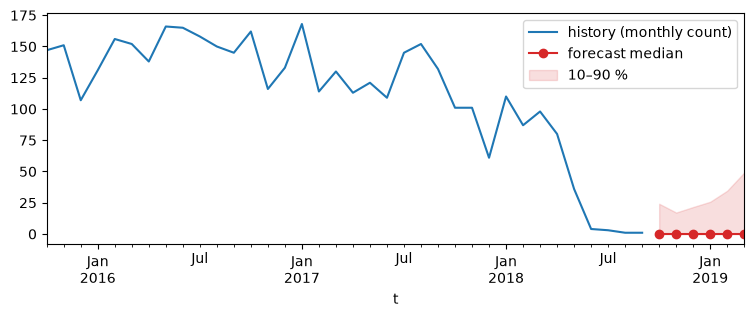

In [5]:
import pandas as pd, matplotlib.pyplot as plt
review = p.table("review").to_pandas()
review["review_time"] = pd.to_datetime(review["review_time"])
hist = review.set_index("review_time").resample("ME")["rating"].count().tail(36)
f = pd.DataFrame([{"t": pd.to_datetime(pt["timestamp"]), "median": pt["median"],
                   "lo": (pt.get("quantiles") or {}).get("0.1", (pt.get("quantiles") or {}).get(0.1)),
                   "hi": (pt.get("quantiles") or {}).get("0.9", (pt.get("quantiles") or {}).get(0.9))} for pt in fc["forecast"]]).set_index("t")
ax = hist.plot(figsize=(9, 3), label="history (monthly count)")
f["median"].plot(ax=ax, color="tab:red", marker="o", label="forecast median")
ax.fill_between(f.index, f["lo"].astype(float), f["hi"].astype(float), color="tab:red", alpha=0.15, label="10–90 %")
ax.legend(); plt.show()

In [6]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "07_forecast_review_volume", "task": "forecast · monthly review count + mean rating (zero-shot)", "model": "Chronos-2 (zero-shot)",
                   "project_id": p.id, "credits_charged_this_run": charged,
                   "headline": {"horizon_months": fc["window_length"], "calibrated": fc.get("calibrated"),
                                "next_month_reviews_median": round(fc["forecast"][0]["median"], 2) if fc["forecast"] else None,
                                "next_month_mean_rating_median": round(fr["forecast"][0]["median"], 2) if fr["forecast"] else None,
                                "note": "zero-shot: no held-out metric by design"}})

wrote results/metrics.json


PosixPath('results/metrics.json')